## 1. Import Libraries

In [1]:
import numpy as np
import cv2
import yaml
from scipy import ndimage
from scipy.interpolate import splprep, splev
from scipy.spatial import distance
from scipy.ndimage import distance_transform_edt
from skimage.morphology import skeletonize, medial_axis
import matplotlib.pyplot as plt

# Enable inline plotting
%matplotlib inline

## 2. Configuration

In [23]:
# File paths
PGM_FILE = 'base_map.pgm'
YAML_FILE = 'base_map.yaml'
OUTPUT_FILE = 'raceline_generated.csv'

# Parameters
NUM_WAYPOINTS = 50
SAFETY_MARGIN = 0.15  # meters
DISTANCE_THRESHOLD = 0.30  # 30% of max distance from walls
OPTIMIZATION_ITERATIONS = 50
LEARNING_RATE = 0.3

## 3. Load Map and Metadata

Map size: (208, 172)
Map resolution: 0.05 m/pixel
Map origin: [-3.679137, -1.55, 0.0]


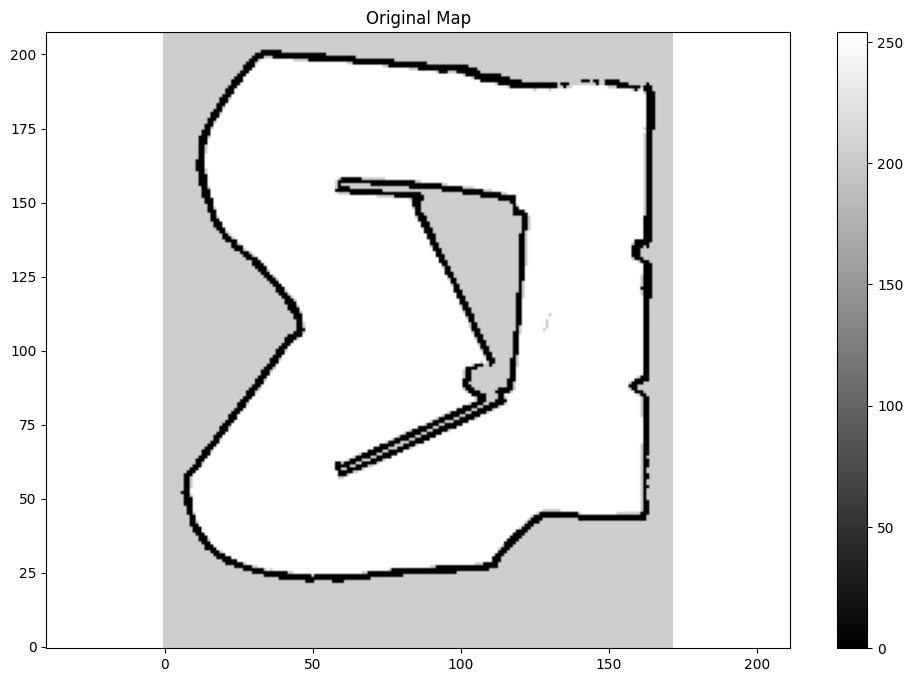

In [24]:
# Load PGM image
map_image = cv2.imread(PGM_FILE, cv2.IMREAD_GRAYSCALE)
if map_image is None:
    raise ValueError(f"Failed to load map image: {PGM_FILE}")

print(f"Map size: {map_image.shape}")

# Load YAML metadata
try:
    with open(YAML_FILE, 'r') as f:
        map_metadata = yaml.safe_load(f)
        resolution = map_metadata.get('resolution', 0.05)
        origin = map_metadata.get('origin', [0.0, 0.0, 0.0])
        print(f"Map resolution: {resolution} m/pixel")
        print(f"Map origin: {origin}")
except Exception as e:
    print(f"Warning: Could not load YAML metadata: {e}")
    resolution = 0.05
    origin = [0.0, 0.0, 0.0]

# Visualize original map
plt.figure(figsize=(12, 8))
plt.imshow(map_image, cmap='gray', origin='lower')
plt.title('Original Map')
plt.axis('equal')
plt.colorbar()
plt.show()

## 4. Extract Track Boundaries

Initial free space: 19751 pixels
Largest track component: 19751 pixels
Track area after safety margin: 19164 pixels


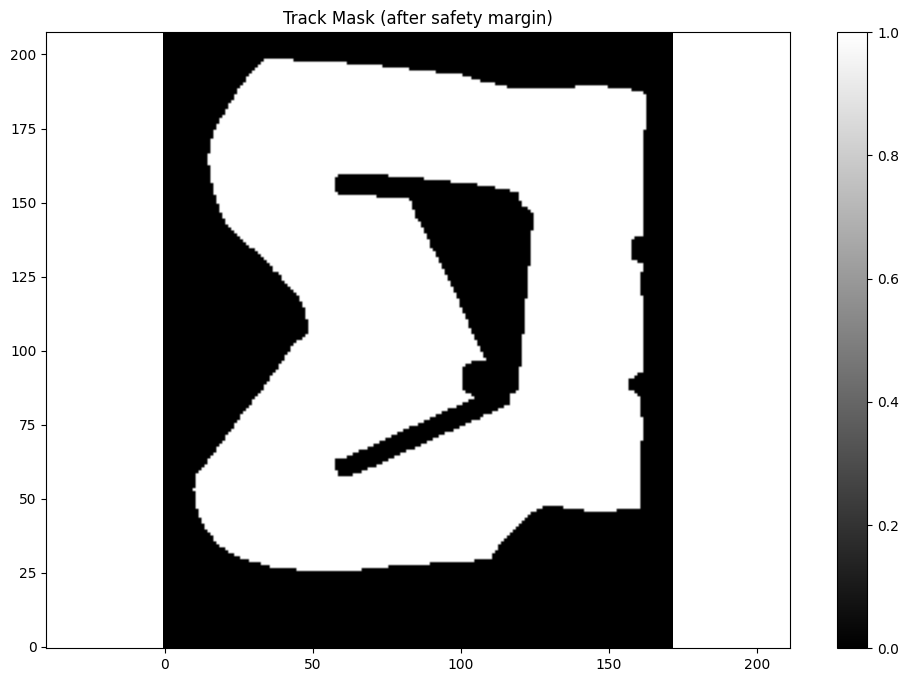

In [25]:
# Extract free space (white pixels = drivable area)
free_threshold = 254
track_mask = (map_image >= free_threshold).astype(np.uint8)
print(f"Initial free space: {np.sum(track_mask)} pixels")

# Find largest connected component (main track)
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(track_mask, connectivity=8)
if num_labels <= 1:
    raise ValueError("No track found in the map")

largest_component = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
track_mask = (labels == largest_component).astype(np.uint8)
print(f"Largest track component: {np.sum(track_mask)} pixels")

# Fill small holes
kernel = np.ones((3, 3), np.uint8)
track_mask = cv2.morphologyEx(track_mask, cv2.MORPH_CLOSE, kernel, iterations=1)

# Apply safety margin
safety_margin_pixels = int(SAFETY_MARGIN / resolution)
kernel_erode = np.ones((safety_margin_pixels, safety_margin_pixels), np.uint8)
track_mask = cv2.erode(track_mask, kernel_erode, iterations=1)
print(f"Track area after safety margin: {np.sum(track_mask)} pixels")

# Visualize track mask
plt.figure(figsize=(12, 8))
plt.imshow(track_mask, cmap='gray', origin='lower')
plt.title('Track Mask (after safety margin)')
plt.axis('equal')
plt.colorbar()
plt.show()

## 5. Compute Centerline via Distance Transform

Distance transform max: 27.20 pixels
Points after distance threshold: 11293
Skeleton points after thinning: 457


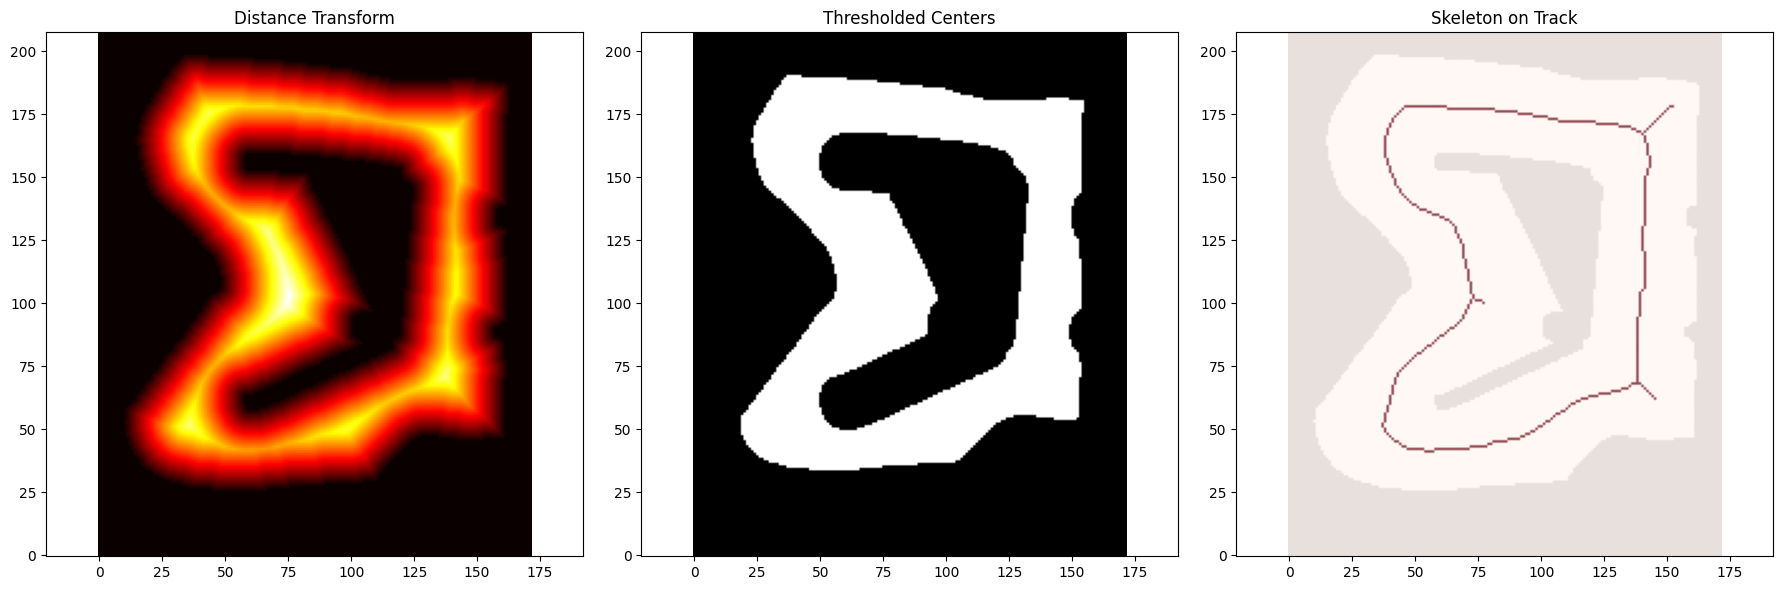

In [26]:
# Calculate Euclidean Distance Transform
dist_transform = distance_transform_edt(track_mask)
print(f"Distance transform max: {dist_transform.max():.2f} pixels")

# Threshold to get centerline
centers = dist_transform > DISTANCE_THRESHOLD * dist_transform.max()
print(f"Points after distance threshold: {np.sum(centers)}")

# Skeletonize to get 1-pixel wide line
skeleton = skeletonize(centers)
print(f"Skeleton points after thinning: {np.sum(skeleton)}")

# Visualize distance transform and skeleton
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(dist_transform, cmap='hot', origin='lower')
axes[0].set_title('Distance Transform')
axes[0].axis('equal')

axes[1].imshow(centers, cmap='gray', origin='lower')
axes[1].set_title('Thresholded Centers')
axes[1].axis('equal')

axes[2].imshow(track_mask, cmap='gray', origin='lower', alpha=0.3)
axes[2].imshow(skeleton, cmap='Reds', origin='lower', alpha=0.7)
axes[2].set_title('Skeleton on Track')
axes[2].axis('equal')

plt.tight_layout()
plt.show()

## 6. Convert to World Coordinates and Order Points

Found 457 centerline points
Ordering centerline points...
Downsampled centerline by step 4, now 109 points
Ordered path has 109 points
Loop closure distance: 0.11m
Downsampled centerline by step 4, now 109 points
Ordered path has 109 points
Loop closure distance: 0.11m


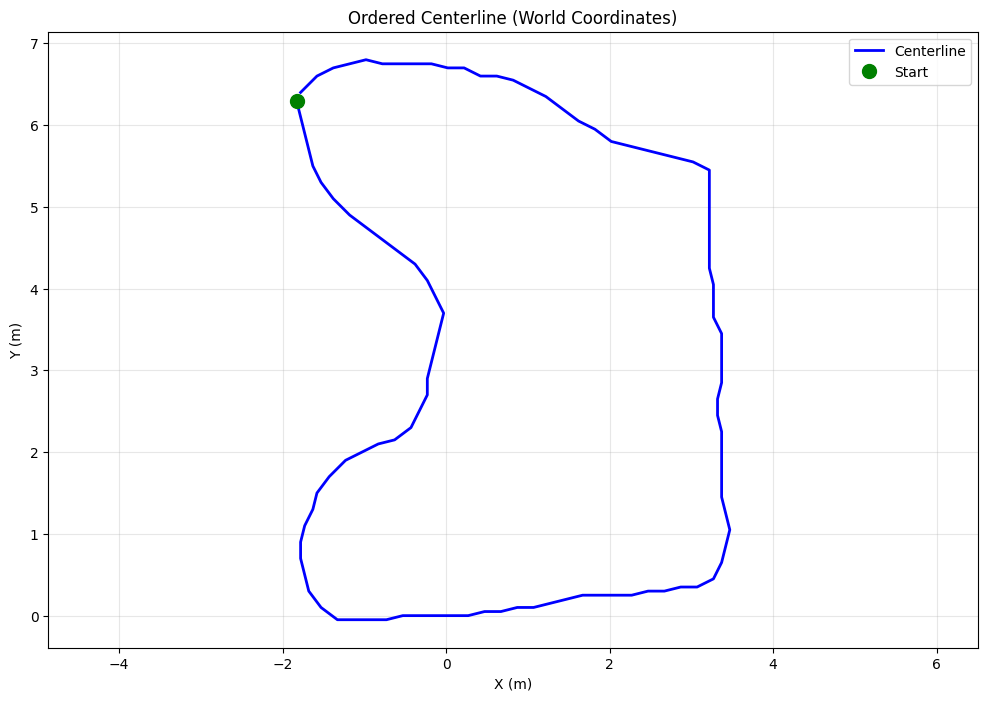

In [32]:
# Extract skeleton points and convert to world coordinates
skeleton_points = np.argwhere(skeleton)
print(f"Found {len(skeleton_points)} centerline points")

centerline_world = []
for point in skeleton_points:
    row, col = point
    x = col * resolution + origin[0]
    y = (map_image.shape[0] - row) * resolution + origin[1]
    centerline_world.append([x, y])

centerline = np.array(centerline_world)

# Order points using greedy nearest-neighbor
print("Ordering centerline points...")
start_idx = np.argmin(centerline[:, 0])
visited = np.zeros(len(centerline), dtype=bool)
ordered_points = []
current_idx = start_idx
max_step = 0.2  # meters

while not visited[current_idx]:
    visited[current_idx] = True
    ordered_points.append(centerline[current_idx])
    
    min_dist = float('inf')
    next_idx = None
    
    for i in range(len(centerline)):
        if not visited[i]:
            dist = np.linalg.norm(centerline[current_idx] - centerline[i])
            if dist < min_dist and dist <= max_step:
                min_dist = dist
                next_idx = i
    
    if next_idx is None:
        break
    
    current_idx = next_idx

centerline = np.array(ordered_points)

# Downsample the ordered centerline to reduce noise and speed up optimization
# Choose a step so we keep roughly a few times more points than final waypoints
# but avoid overly dense centerlines from skeletonization.
desired_points = max(NUM_WAYPOINTS, 100)
if len(centerline) > desired_points:
    step_ds = max(1, len(centerline) // desired_points)
    centerline = centerline[::step_ds]
    print(f"Downsampled centerline by step {step_ds}, now {len(centerline)} points")
else:
    print(f"Centerline length {len(centerline)}; no downsampling applied")

print(f"Ordered path has {len(centerline)} points")

# Check if closed loop
loop_distance = np.linalg.norm(centerline[-1] - centerline[0])
print(f"Loop closure distance: {loop_distance:.2f}m")

if 0.5 < loop_distance < 1.0:
    centerline = np.vstack([centerline, centerline[0]])
    print("Added closure point")

# Visualize centerline
plt.figure(figsize=(12, 8))
plt.plot(centerline[:, 0], centerline[:, 1], 'b-', linewidth=2, label='Centerline')
plt.plot(centerline[0, 0], centerline[0, 1], 'go', markersize=10, label='Start')
plt.title('Ordered Centerline (World Coordinates)')
plt.xlabel('X (m)')
plt.ylabel('Y (m)')
plt.axis('equal')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 7. Optimize Racing Line (Cut Corners)

Optimizing racing line...
Pre-smoothing centerline...
Initial smoothing complete
Iteration 10/50
Iteration 20/50
Iteration 30/50
Iteration 40/50
Iteration 50/50
Optimized raceline has 109 points


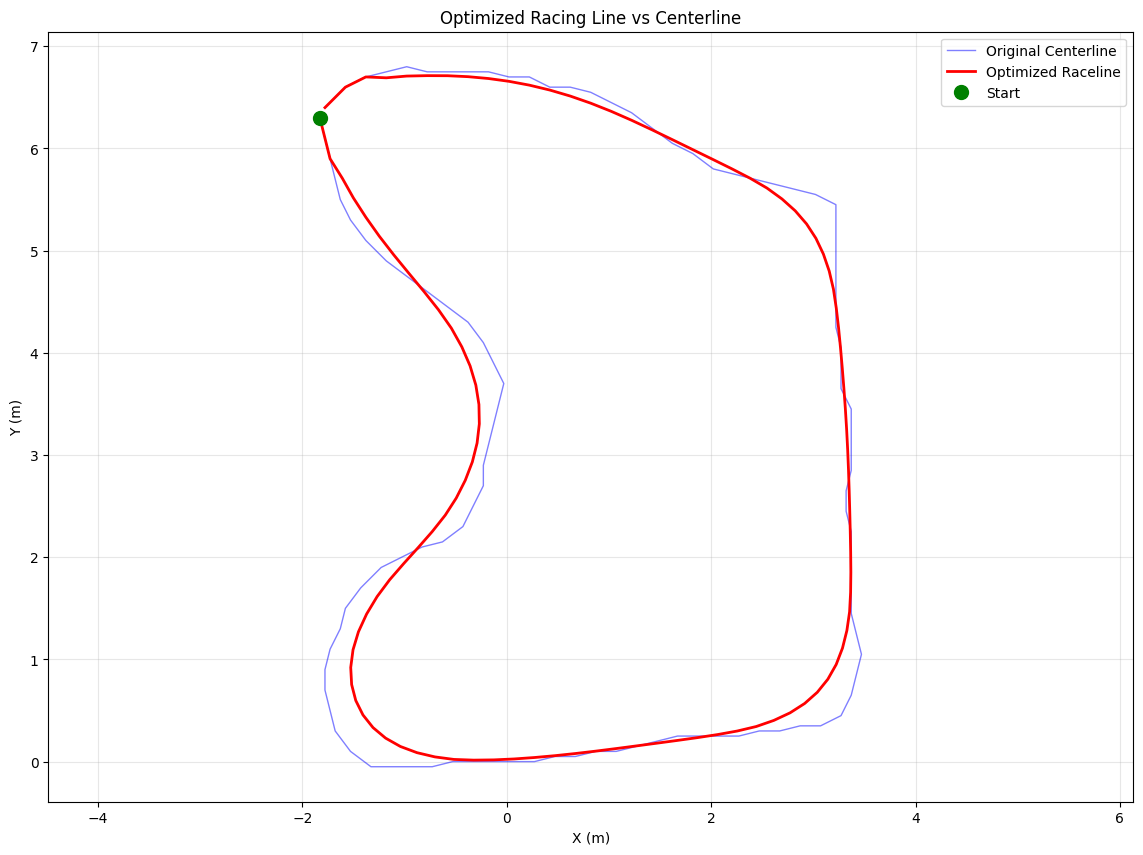

In [33]:
print("Optimizing racing line...")

# Start with heavily smoothed centerline to remove noise
print("Pre-smoothing centerline...")
raceline = centerline.copy()

# Apply Gaussian-like smoothing multiple times
for smooth_pass in range(10):
    smoothed = raceline.copy()
    for i in range(3, len(raceline) - 3):
        # Weighted average with neighbors
        weights = np.array([0.1, 0.2, 0.4, 0.2, 0.1])
        window = raceline[i-2:i+3]
        smoothed[i] = np.average(window, axis=0, weights=weights)
    raceline = smoothed

print("Initial smoothing complete")

# Now optimize: cut corners while maintaining smooth path
# Based on thesis: minimize ∫√k ds by reducing curvature at corners
for iteration in range(OPTIMIZATION_ITERATIONS):
    new_raceline = raceline.copy()
    
    # Only adjust points at corners (skip first/last few points)
    for i in range(10, len(raceline) - 10):
        # Look at local segment
        p_prev = raceline[i - 1]
        p_curr = raceline[i]
        p_next = raceline[i + 1]
        
        # Vectors
        v1 = p_curr - p_prev
        v2 = p_next - p_curr
        
        len1 = np.linalg.norm(v1)
        len2 = np.linalg.norm(v2)
        
        if len1 < 0.001 or len2 < 0.001:
            continue
        
        # Normalize
        v1_norm = v1 / len1
        v2_norm = v2 / len2
        
        # Curvature (cross product of normalized vectors)
        cross = v1_norm[0] * v2_norm[1] - v1_norm[1] * v2_norm[0]
        
        # Only optimize at significant corners
        if abs(cross) > 0.1:  # Threshold for corner detection
            # Calculate the shortcut direction (straight line from prev to next)
            shortcut_dir = p_next - p_prev
            shortcut_len = np.linalg.norm(shortcut_dir)
            
            if shortcut_len > 0.001:
                shortcut_dir = shortcut_dir / shortcut_len
                
                # Move current point toward the shortcut line
                # This reduces path length and curvature
                to_shortcut = (p_prev + p_next) / 2.0 - p_curr
                
                # MORE AGGRESSIVE for hairpins (tighter corners)
                # Scale aggressiveness based on curvature magnitude
                # Higher curvature (sharper corner) = more aggressive cutting
                aggressiveness = min(abs(cross) * 2.0, 1.5)  # Max 1.5x for very tight hairpins
                step = LEARNING_RATE * 0.3 * aggressiveness * to_shortcut  # Increased from 0.1 to 0.3
                test_point = p_curr + step
                
                # Convert to image coordinates
                img_x = int((test_point[0] - origin[0]) / resolution)
                img_y = int(map_image.shape[0] - (test_point[1] - origin[1]) / resolution)
                
                # Only accept if within track bounds
                if (0 <= img_x < map_image.shape[1] and 
                    0 <= img_y < map_image.shape[0] and 
                    track_mask[img_y, img_x] > 0):
                    new_raceline[i] = test_point
    
    raceline = new_raceline
    
    if (iteration + 1) % 10 == 0:
        print(f"Iteration {iteration + 1}/{OPTIMIZATION_ITERATIONS}")

print(f"Optimized raceline has {len(raceline)} points")

# Visualize optimization result
plt.figure(figsize=(14, 10))
plt.plot(centerline[:, 0], centerline[:, 1], 'b-', linewidth=1, alpha=0.5, label='Original Centerline')
plt.plot(raceline[:, 0], raceline[:, 1], 'r-', linewidth=2, label='Optimized Raceline')
plt.plot(raceline[0, 0], raceline[0, 1], 'go', markersize=10, label='Start')
plt.title('Optimized Racing Line vs Centerline')
plt.xlabel('X (m)')
plt.ylabel('Y (m)')
plt.axis('equal')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 8. Downsample to Waypoints

Downsampling to 50 waypoints...
Generated 55 waypoints


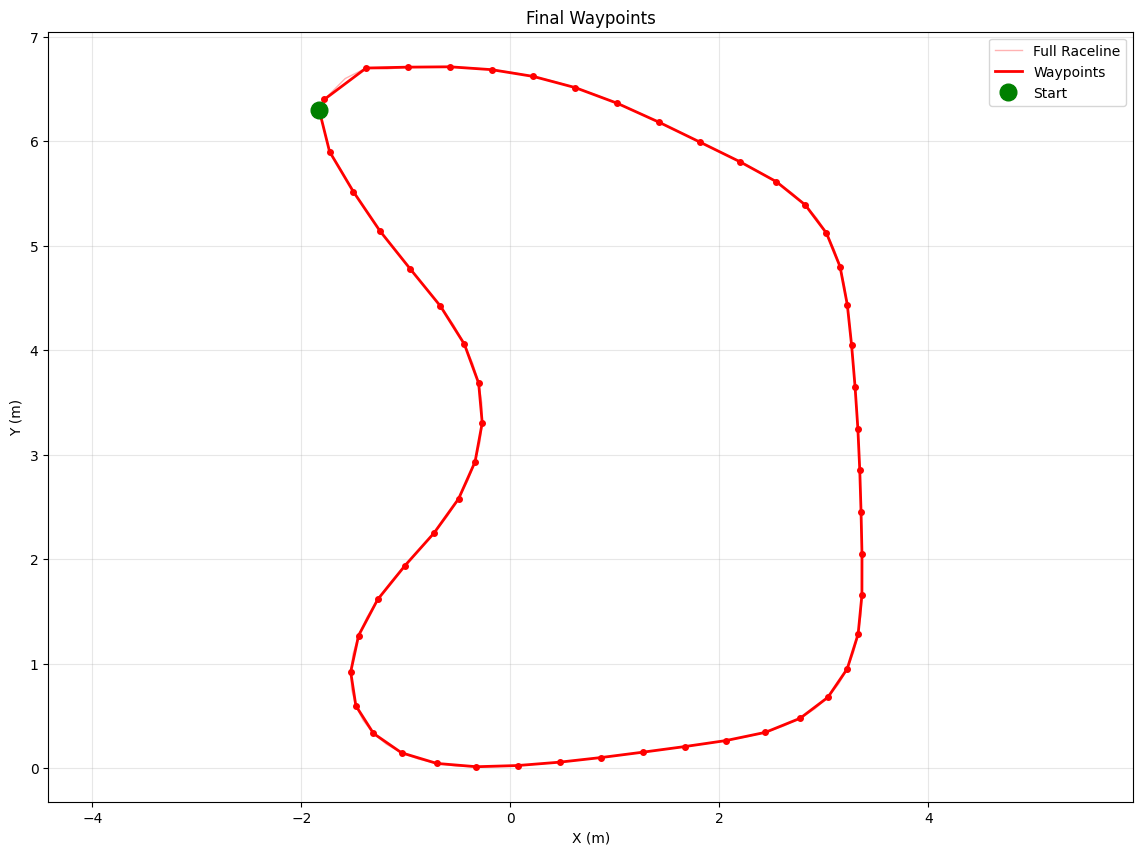

In [ ]:
NUM_WAYPOINTS = 200

print(f"Downsampling to {NUM_WAYPOINTS} waypoints...")

step = max(1, len(raceline) // NUM_WAYPOINTS)
waypoints = raceline[::step]

# Ensure closed loop
is_closed = np.linalg.norm(raceline[-1] - raceline[0]) < 0.5
if is_closed and len(waypoints) > 0:
    if np.linalg.norm(waypoints[-1] - waypoints[0]) > 0.3:
        waypoints = np.vstack([waypoints, waypoints[0]])

print(f"Generated {len(waypoints)} waypoints")

# Visualize final waypoints
plt.figure(figsize=(14, 10))
plt.plot(raceline[:, 0], raceline[:, 1], 'r-', linewidth=1, alpha=0.3, label='Full Raceline')
plt.plot(waypoints[:, 0], waypoints[:, 1], 'r-', linewidth=2, label='Waypoints')
plt.plot(waypoints[:, 0], waypoints[:, 1], 'ro', markersize=4)
plt.plot(waypoints[0, 0], waypoints[0, 1], 'go', markersize=12, label='Start')
plt.title('Final Waypoints')
plt.xlabel('X (m)')
plt.ylabel('Y (m)')
plt.axis('equal')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 9. Save Waypoints to CSV

In [30]:
print(f"Saving waypoints to {OUTPUT_FILE}...")

with open(OUTPUT_FILE, 'w') as f:
    for point in waypoints:
        f.write(f"{point[0]:.2f},{point[1]:.2f},0.0,1.0\n")

print(f"Saved {len(waypoints)} waypoints")
print(f"\n=== Raceline Generation Complete ===")
print(f"Output file: {OUTPUT_FILE}")

Saving waypoints to raceline_generated.csv...
Saved 55 waypoints

=== Raceline Generation Complete ===
Output file: raceline_generated.csv


## 10. Final Visualization

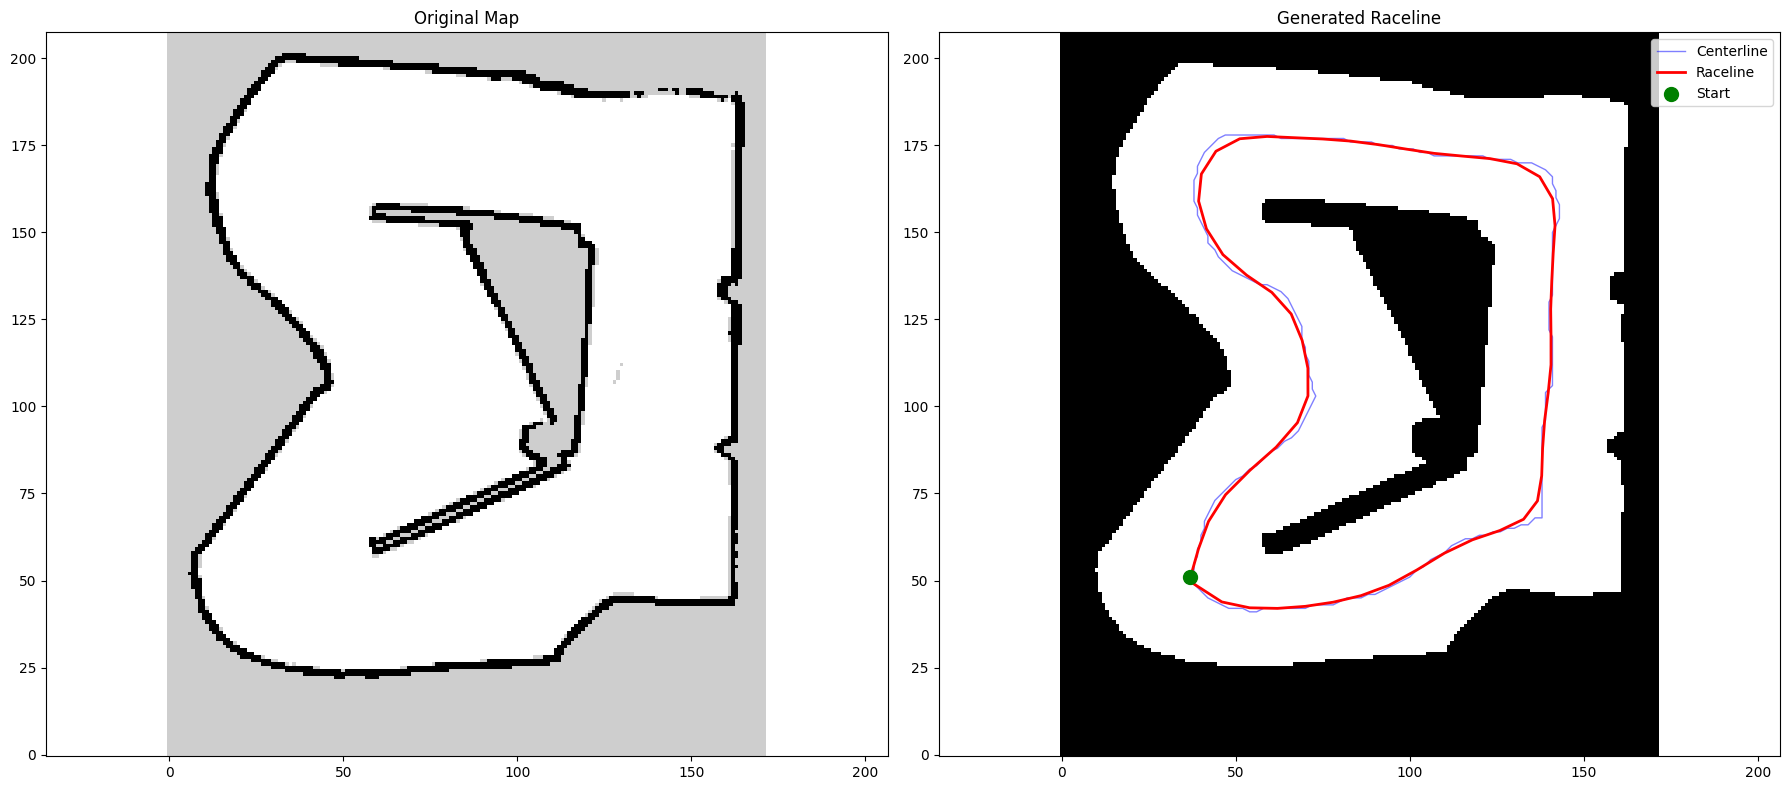

Visualization saved!


In [31]:
# Convert waypoints back to image coordinates for overlay
def world_to_image(points, resolution, origin, img_height):
    points_img = np.zeros_like(points)
    points_img[:, 1] = (points[:, 0] - origin[0]) / resolution
    points_img[:, 0] = img_height - (points[:, 1] - origin[1]) / resolution
    return points_img

centerline_img = world_to_image(centerline, resolution, origin, map_image.shape[0])
waypoints_img = world_to_image(waypoints, resolution, origin, map_image.shape[0])

# Final visualization with map overlay
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Original map
axes[0].imshow(map_image, cmap='gray', origin='lower')
axes[0].set_title('Original Map')
axes[0].axis('equal')

# Raceline on map
axes[1].imshow(track_mask, cmap='gray', origin='lower')
axes[1].plot(centerline_img[:, 1], centerline_img[:, 0], 'b-', 
            linewidth=1, alpha=0.5, label='Centerline')
axes[1].plot(waypoints_img[:, 1], waypoints_img[:, 0], 'r-', 
            linewidth=2, label='Raceline')
axes[1].scatter(waypoints_img[0, 1], waypoints_img[0, 0], 
               c='green', s=100, zorder=5, label='Start')
axes[1].set_title('Generated Raceline')
axes[1].legend()
axes[1].axis('equal')

plt.tight_layout()
plt.savefig(OUTPUT_FILE.replace('.csv', '_visualization.png'), dpi=150, bbox_inches='tight')
plt.show()

print("Visualization saved!")